# 저소득이 당뇨에 더 많이 노출되어 있는가

소득이 낮은 집단일수록 당뇨병에 더 많이 노출된다는 보도를 보고 이 분석을 시작했다. 이 노트북은 그 질문을 두 단계로 나눠 확인한다.

1. **연관**: 소득이 낮을수록 당뇨 유병률이 실제로 높은가? 다른 요인(연령·성별·교육·BMI)을 통제해도 그 관계가 남는가?
2. **예측력**: 그 연관이 통계적으로 유의하다는 것과, 소득 하나만으로 개인의 당뇨 여부를 실제로 가려낼 수 있다는 것은 다른 문제다. 소득 하나만 놓고 당뇨를 예측하면 얼마나 맞힐 수 있는가?

BRFSS 2015 당뇨병 건강지표 데이터셋을 이용해 소득(`Income`)과 당뇨(`Diabetes_binary`)의 관계를 회귀분석과 예측모델링 양쪽에서 확인한다.

**실행 환경**: Python 3.14, 저장소 루트의 `pyproject.toml`/`uv.lock` 기준. 저장소 루트에서 `uv sync`로 의존성을 설치한 뒤 `uv run jupyter lab notebooks/2.0-income-diabetes-predictive-power.ipynb`로 열거나, `uv run jupyter nbconvert --to notebook --execute --inplace notebooks/2.0-income-diabetes-predictive-power.ipynb`로 전체를 재실행할 수 있다. `data/raw/diabetes_binary_health_indicators_BRFSS2015.csv`가 먼저 준비돼 있어야 한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = "../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(253680, 22)

## 1. 데이터

- **이 데이터를 고른 이유**: 이 데이터셋은 소득(`Income`)과 당뇨 진단 여부(`Diabetes_binary`)를 함께 담고 있을 뿐 아니라, 연령·성별·교육·BMI·혈압·콜레스테롤 같은 인구통계·임상 지표까지 포함한다. 덕분에 "소득과 당뇨가 연관되는가"라는 질문을 회귀분석으로 확인하는 데 그치지 않고, 그 연관이 예측에 실제로 쓸모 있는 신호인지까지 같은 데이터 안에서 검증할 수 있다.
- **출처**: CDC BRFSS(Behavioral Risk Factor Surveillance System) 2015 설문조사를 기반으로 가공된 공개 파생 데이터셋(Diabetes Health Indicators Dataset). 컬럼 전체 목록과 코드북은 [`references/data_dictionary.md`](../references/data_dictionary.md)에 정리돼 있다.
- **행 하나의 의미**: 2015년 미국 CDC BRFSS 전화 설문에 응답한 성인 1명
- **규모**: 253,680행 × 22열
- **이 분석에서 쓰는 핵심 컬럼**: `Income`(소득 구간, 1=최저~8=최고), `Diabetes_binary`(당뇨 진단 여부, 타깃). 예측모델의 상한선을 보기 위한 참조 모델에는 인구통계·임상·생활습관 지표를 포함한 전체 21개 컬럼을 함께 쓴다.
- 용량 문제로 저장소에는 원본 CSV를 포함하지 않았다.

In [2]:
print("Missing values total:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum(), f"({df.duplicated().mean():.1%})")
print("Income 값 범위:", sorted(df['Income'].unique()))
print("Diabetes_binary 값 범위:", sorted(df['Diabetes_binary'].unique()))

Missing values total: 0
Duplicate rows: 24206 (9.5%)
Income 값 범위: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]
Diabetes_binary 값 범위: [np.float64(0.0), np.float64(1.0)]


결측치는 없고, 전체의 9.5%가 완전 중복행이다. 모든 변수가 구간화된 범주형 코드이고 표본이 25만 행으로 크기 때문에 서로 다른 응답자가 같은 코드 조합을 가질 가능성이 충분히 있어(입력 오류로 보기 어려움), 삭제하지 않고 전체 표본을 그대로 쓴다. `Income`(1~8)과 `Diabetes_binary`(0/1)의 값 범위도 코드북과 일치한다.

지금까지는 `Income`·`Diabetes_binary`만 점검했다. Full 모델(참조선)에는 나머지 20개 변수도 함께 쓰이므로, 이 변수들의 자료형과 이 데이터셋에서 유일한 연속형 변수인 `BMI`의 이상치도 확인한다.

전체 컬럼 dtype: [dtype('float64')]
고유값 8개 이하 변수: 16 / 20

BMI 기술통계:


count    253680.000000
mean         28.382364
std           6.608694
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          98.000000
Name: BMI, dtype: float64
IQR 기준 정상 범위: 13.5 ~ 41.5
이상치 비율: 3.88%


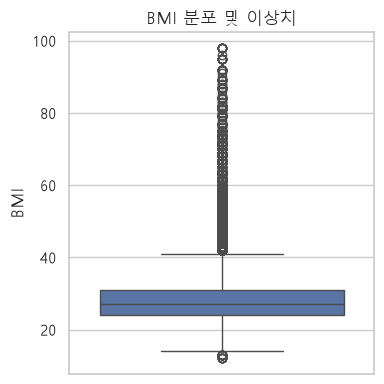

In [3]:
other_features = [c for c in df.columns if c not in ("Income", "Diabetes_binary")]
print("전체 컬럼 dtype:", df.dtypes.unique())
print(f"고유값 8개 이하 변수: {(df[other_features].nunique() <= 8).sum()} / {len(other_features)}")
print()
print("BMI 기술통계:")
print(df["BMI"].describe())

q1, q3 = df["BMI"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_ratio = ((df["BMI"] < lower) | (df["BMI"] > upper)).mean()
print(f"IQR 기준 정상 범위: {lower:.1f} ~ {upper:.1f}")
print(f"이상치 비율: {outlier_ratio:.2%}")

fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(y=df["BMI"], ax=ax, color="#4C72B0")
ax.set_title("BMI 분포 및 이상치")
plt.tight_layout()
plt.show()

22개 컬럼은 전부 `float64`로 저장돼 있지만, 그중 18개(`Income`·`Diabetes_binary` 포함)는 고유값이 8개 이하라 사실상 이진 또는 순서형 코드다. 나머지 4개(`BMI`, `MentHlth`, `PhysHlth`, `Age`)는 값의 폭이 더 넓다 — `Age`(1~13)는 순서형 구간이 더 세분화된 경우고, `MentHlth`·`PhysHlth`는 지난 30일 중 며칠이었는지를 세는 카운트형(0~30)이며, `BMI`만 진짜 연속형이다. 유일한 연속형 변수인 `BMI`는 IQR 기준 이상치 비율이 3.9%이고 최댓값(98)도 고도비만에 해당하는, 의학적으로 존재 가능한 값이라 삭제·절단 없이 그대로 둔다 — 다만 Full 모델의 계수 추정에 이 값들이 어느 정도 영향을 줄 수 있다는 점은 감안해서 해석해야 한다.

## 2. EDA: 타깃 분포와 소득별 당뇨 유병률

Diabetes_binary
0.0    0.8607
1.0    0.1393
Name: proportion, dtype: float64


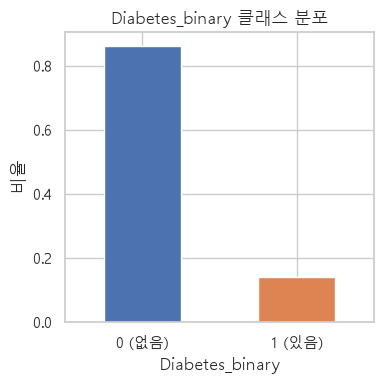

In [4]:
diabetes_ratio = df["Diabetes_binary"].value_counts(normalize=True).sort_index()
print(diabetes_ratio.round(4))

fig, ax = plt.subplots(figsize=(4, 4))
diabetes_ratio.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["0 (없음)", "1 (있음)"], rotation=0)
ax.set_ylabel("비율")
ax.set_title("Diabetes_binary 클래스 분포")
plt.tight_layout()
plt.show()

양성(당뇨 있음)이 13.9%, 음성이 86.1%로 약 6.2:1의 클래스 불균형이다. 정확도만으로 예측모델을 평가하면 "무조건 없음"으로 예측해도 86%가 나오는 함정이 있으므로, 이후 예측모델링에서는 ROC-AUC와 재현율을 함께 본다.

이어서 소득 구간별 당뇨 유병률을 확인한다.

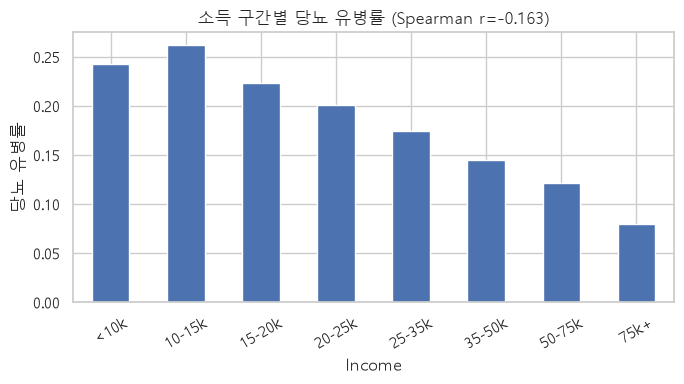

Income
<10k      0.2429
10-15k    0.2619
15-20k    0.2231
20-25k    0.2013
25-35k    0.1740
35-50k    0.1451
50-75k    0.1218
75k+      0.0796
Name: Diabetes_binary, dtype: float64

In [5]:
income_labels = {1: "<10k", 2: "10-15k", 3: "15-20k", 4: "20-25k", 5: "25-35k",
                 6: "35-50k", 7: "50-75k", 8: "75k+"}
income_order = [income_labels[i] for i in range(1, 9)]

rate_by_income = df.groupby("Income")["Diabetes_binary"].mean().rename(index=income_labels).reindex(income_order)
spearman_corr = df["Income"].corr(df["Diabetes_binary"], method="spearman")

fig, ax = plt.subplots(figsize=(7, 4))
rate_by_income.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("당뇨 유병률")
ax.set_title(f"소득 구간별 당뇨 유병률 (Spearman r={spearman_corr:.3f})")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

rate_by_income.round(4)

최하위 소득군(<10k)의 당뇨 유병률은 24.3%로 최상위군(75k+) 8.0%의 3배다. 소득 구간이 오를수록 유병률이 거의 단조적으로 감소하며(스피어만 상관 -0.163), 중간에 눈에 띄는 예외는 10-15k 구간(26.2%)뿐이다 — 최하위군보다도 소폭 높다.

## 3. 소득은 당뇨와 독립적으로 연관되는가: 로지스틱 회귀(오즈비)

소득과 당뇨가 함께 움직인다는 것을 확인했지만, 이 관계가 연령·성별·교육·체중처럼 소득과 당뇨 둘 다에 영향을 줄 수 있는 다른 요인 때문에 생긴 착시일 수 있다. `Age`, `Sex`, `Education`, `BMI`를 교란변수로 통제한 모델과 비교해 소득의 독립적 효과가 남는지 확인한다.

In [6]:
unadj_model = smf.logit("Diabetes_binary ~ Income", data=df).fit(disp=0)
adj_model = smf.logit("Diabetes_binary ~ Income + Age + Sex + Education + BMI", data=df).fit(disp=0)

def or_row(model, label):
    or_ = np.exp(model.params["Income"])
    ci = np.exp(model.conf_int().loc["Income"]).values
    return {"model": label, "odds_ratio": or_, "ci_low": ci[0], "ci_high": ci[1], "p_value": model.pvalues["Income"]}

income_or = pd.DataFrame([
    or_row(unadj_model, "비보정 (Income만)"),
    or_row(adj_model, "보정 (Age, Sex, Education, BMI 통제)"),
])
income_or.round(4)

,model,odds_ratio,ci_low,ci_high,p_value
0,비보정 (Income만),0.8129,0.8088,0.8170,0.0
1,"보정 (Age, Sex, Education, BMI 통제)",0.8608,0.8555,0.8661,0.0


표로 본 값을 막대그래프로 함께 비교한다. 막대는 오즈비 점추정치이고, 검은색 오차막대는 95% 신뢰구간이다. 신뢰구간이 회색 점선(OR=1, "효과 없음" 기준선)과 겹치지 않으면 그 소득 효과가 통계적으로 유의하다는 뜻이고, 막대 옆 괄호 안 숫자는 신뢰구간 범위를 그대로 적은 것이다.

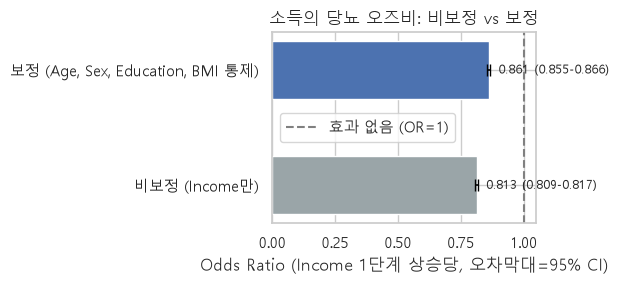

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
xerr = [
    (income_or["odds_ratio"] - income_or["ci_low"]).values,
    (income_or["ci_high"] - income_or["odds_ratio"]).values,
]
ax.barh(income_or["model"], income_or["odds_ratio"], xerr=xerr, capsize=4,
        color=["#9AA5A8", "#4C72B0"], height=0.5, error_kw={"ecolor": "black", "elinewidth": 1.2})
for i, row in income_or.iterrows():
    ax.annotate(f"{row['odds_ratio']:.3f} ({row['ci_low']:.3f}-{row['ci_high']:.3f})",
                (row["ci_high"], i), textcoords="offset points", xytext=(6, 0), va="center", fontsize=9)
ax.axvline(1, color="gray", linestyle="--", label="효과 없음 (OR=1)")
ax.set_xlabel("Odds Ratio (Income 1단계 상승당, 오차막대=95% CI)")
ax.set_title("소득의 당뇨 오즈비: 비보정 vs 보정")
ax.legend()
plt.tight_layout()
plt.show()

`Income`은 1(최저)~8(최고)로 코딩돼 있어 OR<1은 소득이 높을수록 당뇨 위험이 낮다는 뜻이다. 비보정 오즈비는 0.813(95% CI 0.809–0.817), 연령·성별·교육·BMI를 통제한 후에도 0.861(95% CI 0.855–0.866, p<0.001)로 여전히 강하게 유의하다 — 그래프에서 두 오차막대 모두 기준선(OR=1)에서 뚜렷이 떨어져 있고 서로 겹치지 않는 것에서도 확인된다. 교란변수를 통제하면서 오즈비가 1 쪽으로 다소 움직이긴 했지만(원시 연관의 일부는 다른 인구통계 요인과 얽혀 있었다는 뜻), 소득 자체의 독립적 효과는 뚜렷하게 남는다. **소득이 낮을수록 당뇨 위험이 높다는 것은 다른 요인으로 완전히 설명되지 않는 독립적인 연관이다.**

## 4. 소득 하나만으로 당뇨를 예측할 수 있는가

지금까지는 "연관이 통계적으로 유의한가"를 봤다. 이번에는 관점을 바꿔 **소득 하나만 갖고 개인의 당뇨 여부를 얼마나 잘 맞힐 수 있는지**를 확인한다. 통계적으로 유의한 연관이 있어도 실제 예측에는 쓸모없는 경우가 흔하므로, 이 둘을 구분해서 봐야 한다.

- **Baseline**: 항상 최빈 클래스("당뇨 아님")로 예측하는 `DummyClassifier`
- **Model I (income-only)**: `Income` 1개 변수만 사용
- **Model F (full)**: `Diabetes_binary`를 제외한 21개 변수 모두 사용 — 예측력의 상한선을 보여주는 참조선

`Income`은 순서형 정수 코드(1~8)라 연속형처럼 다루는 것이 타당한지도 확인한다. Model I을 세 가지 방식으로 적합한다: (1) 로지스틱 회귀로 순서형 그대로, (2) 로지스틱 회귀로 8개 범주를 원-핫 인코딩, (3) 비선형 관계까지 잡아낼 수 있는 트리 기반 모델(`HistGradientBoostingClassifier`)로 순서형 그대로. 세 방식의 성능이 비슷하면 순서형-선형 취급이 정보를 잃지 않는다는 뜻이다.

**검증 방식**: 데이터는 `train_test_split`으로 75/25 분할하되 `stratify`로 클래스 비율을 유지하고, 분할 하나에 결과가 좌우되지 않도록 5-fold 층화 교차검증으로 재확인한다. `StandardScaler`는 `Pipeline` 안에 넣어 학습 폴드에서만 평균·표준편차를 추정하게 해, 테스트 데이터 정보가 전처리 단계에서 새어 들어가는 데이터 누수를 막는다.

In [8]:
income_features = ["Income"]
full_features = [c for c in df.columns if c != "Diabetes_binary"]

X_train_i, X_test_i, y_train, y_test = train_test_split(
    df[income_features], df["Diabetes_binary"], test_size=0.25, stratify=df["Diabetes_binary"], random_state=42
)
X_train_f, X_test_f, _, _ = train_test_split(
    df[full_features], df["Diabetes_binary"], test_size=0.25, stratify=df["Diabetes_binary"], random_state=42
)


def build_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    ])


def build_tree():
    return HistGradientBoostingClassifier(class_weight="balanced", random_state=42)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
# 방식 1: 순서형(연속형처럼) 로지스틱 회귀
pipe_i = build_pipeline().fit(X_train_i, y_train)
proba_i = pipe_i.predict_proba(X_test_i)[:, 1]
auc_i = roc_auc_score(y_test, proba_i)
cv_auc_i = cross_val_score(build_pipeline(), df[income_features], df["Diabetes_binary"], cv=cv, scoring="roc_auc")

# 방식 2: 8개 범주 원-핫 로지스틱 회귀
X_train_icat = pd.get_dummies(df.loc[X_train_i.index, "Income"].astype(int), prefix="Income")
X_test_icat = pd.get_dummies(df.loc[X_test_i.index, "Income"].astype(int), prefix="Income")
X_test_icat = X_test_icat.reindex(columns=X_train_icat.columns, fill_value=0)
pipe_icat = Pipeline([("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))])
pipe_icat.fit(X_train_icat, y_train)
proba_icat = pipe_icat.predict_proba(X_test_icat)[:, 1]
auc_icat = roc_auc_score(y_test, proba_icat)

# 방식 3: 트리 기반, 순서형 그대로
tree_i = build_tree().fit(X_train_i, y_train)
proba_i_tree = tree_i.predict_proba(X_test_i)[:, 1]
auc_i_tree = roc_auc_score(y_test, proba_i_tree)
cv_auc_i_tree = cross_val_score(build_tree(), df[income_features], df["Diabetes_binary"], cv=cv, scoring="roc_auc")

income_variants = pd.DataFrame({
    "방식": ["순서형 로지스틱", "8범주 원-핫 로지스틱", "순서형 트리(HistGB)"],
    "holdout_AUC": [auc_i, auc_icat, auc_i_tree],
    "5fold_CV_AUC": [cv_auc_i.mean(), np.nan, cv_auc_i_tree.mean()],
})
income_variants.round(4)

,방식,holdout_AUC,5fold_CV_AUC
0,순서형 로지스틱,0.6310,0.6323
1,8범주 원-핫 로지스틱,0.6315,NaN
2,순서형 트리(HistGB),0.6315,0.6326


표로는 세 방식의 차이가 작아 잘 안 보이니, 막대그래프로 나란히 비교한다.

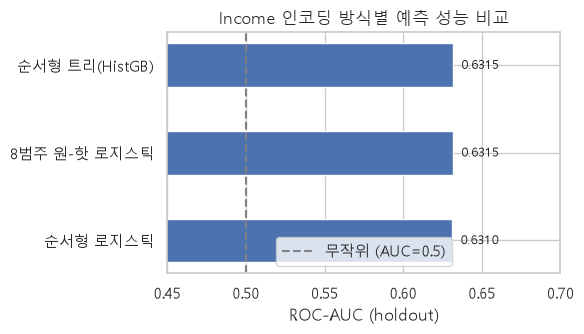

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(income_variants["방식"], income_variants["holdout_AUC"], color="#4C72B0", height=0.5)
for b, v in zip(bars, income_variants["holdout_AUC"]):
    ax.annotate(f"{v:.4f}", (v, b.get_y() + b.get_height() / 2), textcoords="offset points",
                xytext=(6, 0), va="center", fontsize=9)
ax.axvline(0.5, color="gray", linestyle="--", label="무작위 (AUC=0.5)")
ax.set_xlim(0.45, 0.7)
ax.set_xlabel("ROC-AUC (holdout)")
ax.set_title("Income 인코딩 방식별 예측 성능 비교")
ax.legend()
plt.tight_layout()
plt.show()

세 방식의 ROC-AUC가 0.6310~0.6315로 거의 동일하다. 범주를 원-핫으로 풀거나 비선형 모델을 써도 성능이 오르지 않는다는 것은, `Income`을 1~8 순서형 정수로 그대로 넣는 단순한 방식이 정보를 잃지 않는다는 뜻이다. 이후 비교는 순서형 로지스틱 회귀(Model I) 결과로 진행한다.

In [11]:
pipe_f = build_pipeline().fit(X_train_f, y_train)
proba_f = pipe_f.predict_proba(X_test_f)[:, 1]
auc_f = roc_auc_score(y_test, proba_f)
cv_auc_f = cross_val_score(build_pipeline(), df[full_features], df["Diabetes_binary"], cv=cv, scoring="roc_auc")

baseline = DummyClassifier(strategy="most_frequent", random_state=42).fit(X_train_i, y_train)
baseline_pred = baseline.predict(X_test_i)
baseline_acc = (baseline_pred == y_test).mean()

summary = pd.DataFrame({
    "model": ["Baseline (최빈값)", "Model I (Income only)", "Model F (전체 21개)"],
    "holdout_AUC": [0.5, auc_i, auc_f],
    "5fold_CV_AUC": [0.5, cv_auc_i.mean(), cv_auc_f.mean()],
    "CV_std": [0.0, cv_auc_i.std(), cv_auc_f.std()],
})
summary.round(4)

,model,holdout_AUC,5fold_CV_AUC,CV_std
0,Baseline (최빈값),0.5000,0.5000,0.0000
1,Model I (Income only),0.6310,0.6323,0.0036
2,Model F (전체 21개),0.8219,0.8225,0.0033


ROC 곡선으로 두 모델의 판별력 차이를 시각적으로 비교한다.

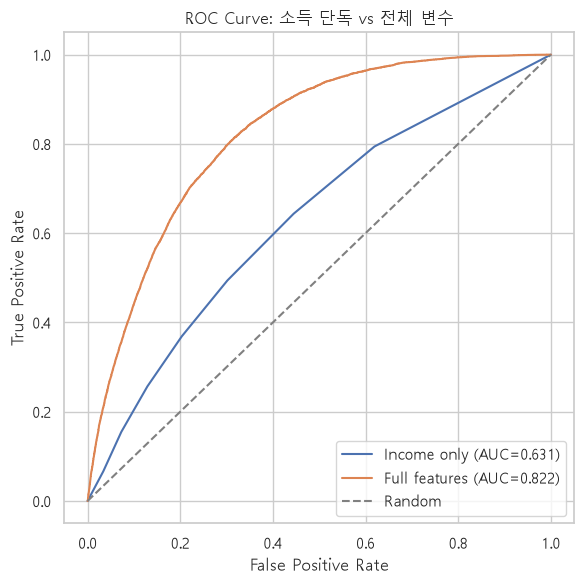

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
for proba, auc, label in [
    (proba_i, auc_i, f"Income only (AUC={auc_i:.3f})"),
    (proba_f, auc_f, f"Full features (AUC={auc_f:.3f})"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: 소득 단독 vs 전체 변수")
ax.legend()
plt.tight_layout()
plt.show()

`Income` 단독 모델의 ROC-AUC는 0.631(5-fold CV 0.632±0.004)로, 무작위(0.5)에서 확실히 벗어난 의미 있는 신호다. 다만 전체 21개 변수를 쓴 Model F(0.822)에는 크게 못 미쳐, 소득 하나로 개인의 당뇨 여부를 확정적으로 가리기엔 부족하다. **소득은 "통계적으로 유의하다"에서 그치지 않고 어느 정도 실질적인 예측 신호까지 갖고 있지만, 그 신호만으로 개인 단위 진단을 대신할 수는 없다.**

## 5. 임계값 0.5에서 분류 성능

ROC-AUC는 임계값 전체를 훑은 요약 지표다. 실제 판정 임계값(0.5)에서 각 모델이 얼마나 다르게 행동하는지 확인한다.

**왜 0.5인가**: 0.5는 예측 확률이 두 클래스 중 어느 쪽에 더 가까운지를 가르는 가장 단순한 기본값이다. 원래 이 데이터처럼 양성 비율이 13.9%로 낮으면 0.5를 그대로 쓸 때 모델이 사실상 항상 다수 클래스로만 판정하는 문제가 흔하다. 하지만 이 노트북의 모델은 모두 학습 단계에서 `class_weight="balanced"`로 클래스 가중치를 이미 보정했으므로, 예측 확률 자체가 두 클래스를 대칭적으로 다루도록 재조정된 상태다 — 그래서 임계값을 따로 튜닝하지 않고 0.5를 써도 한쪽으로 치우치지 않는다. 또한 Baseline·Income-only·Full 세 모델을 같은 기준으로 공정하게 비교하려면 임계값이 통일돼 있어야 하므로, 이 절에서는 0.5를 공통 기준으로 고정한다. 다만 이는 비교를 위한 기본값일 뿐, 실제 서비스에 쓸 때는 목적(예: 스크리닝 대상 인원 예산)에 맞춰 임계값을 조정하는 것이 합리적이다 — 8절 비즈니스 인사이트에서 이어서 다룬다.

In [13]:
def report_row(name, y_true, proba, acc_only=False):
    pred = (proba >= 0.5).astype(int)
    acc = (pred == y_true).mean()
    if acc_only:
        return {"model": name, "accuracy": acc, "precision(양성)": np.nan, "recall(양성)": np.nan}
    cr = classification_report(y_true, pred, output_dict=True)
    return {"model": name, "accuracy": acc, "precision(양성)": cr["1.0"]["precision"], "recall(양성)": cr["1.0"]["recall"]}

rows = [
    report_row("Baseline", y_test, np.zeros_like(y_test), acc_only=True),
    report_row("Model I (Income only)", y_test, proba_i),
    report_row("Model F (전체 21개)", y_test, proba_f),
]
rows[0]["accuracy"] = baseline_acc
threshold_summary = pd.DataFrame(rows)
threshold_summary.round(3)

,model,accuracy,precision(양성),recall(양성)
0,Baseline,0.861,NaN,NaN
1,Model I (Income only),0.670,0.209,0.494
2,Model F (전체 21개),0.733,0.312,0.762


표를 막대그래프로 시각화하면 모델별 정확도-재현율 트레이드오프가 더 뚜렷하게 보인다.

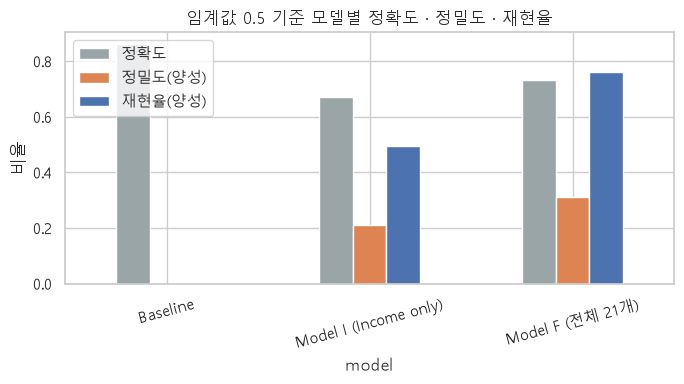

In [14]:
plot_df = threshold_summary.set_index("model")[["accuracy", "precision(양성)", "recall(양성)"]]
fig, ax = plt.subplots(figsize=(7, 4))
plot_df.plot(kind="bar", ax=ax, color=["#9AA5A8", "#DD8452", "#4C72B0"])
ax.set_ylabel("비율")
ax.set_title("임계값 0.5 기준 모델별 정확도 · 정밀도 · 재현율")
ax.tick_params(axis="x", rotation=15)
ax.legend(["정확도", "정밀도(양성)", "재현율(양성)"])
plt.tight_layout()
plt.show()

Income 모델이 어떤 유형의 오류를 내는지 혼동행렬로 좀 더 자세히 살펴본다.

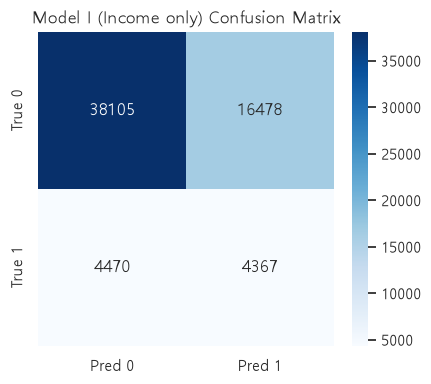

In [15]:
cm_i = confusion_matrix(y_test, (proba_i >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm_i, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"], ax=ax)
ax.set_title("Model I (Income only) Confusion Matrix")
plt.tight_layout()
plt.show()

`Income` 단독 모델은 정확도(67.0%)가 기준선(86.1%)보다 낮아 보이지만, `class_weight="balanced"`로 학습해 양성(당뇨 있음) 재현율을 49.4%까지 끌어올린 결과다 — 기준선은 정의상 양성 재현율이 0%다. 불균형 데이터에서는 정확도만으로 모델을 평가하면 안 되는 이유가 여기서도 확인된다.

## 6. 전체 모델에서 소득의 상대적 위치

`Income`이 단독으로는 의미 있는 신호를 갖지만, 임상·인구통계 지표가 모두 경쟁하는 전체 모델에서는 상대적으로 어느 위치에 있을까. 표준화 로지스틱 회귀 계수 절댓값으로 순위를 매긴다.

전체 21개 변수 중 Income의 중요도 순위: 9위


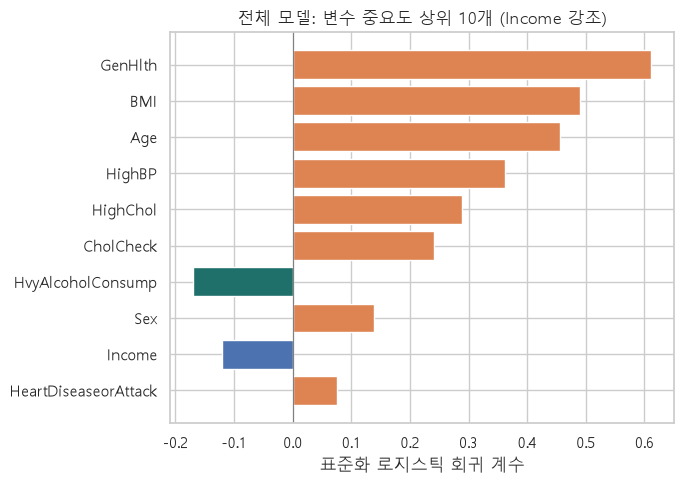

In [16]:
coefs = pipe_f.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": full_features, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)
income_rank = coef_df.index[coef_df["feature"] == "Income"][0] + 1
print(f"전체 21개 변수 중 Income의 중요도 순위: {income_rank}위")

top_n = coef_df.head(10).iloc[::-1]
colors = ["#DD8452" if c > 0 else "#1F6F6B" for c in top_n["coef"]]
colors = [("#4C72B0" if f == "Income" else c) for f, c in zip(top_n["feature"], colors)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_n["feature"], top_n["coef"], color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("표준화 로지스틱 회귀 계수")
ax.set_title("전체 모델: 변수 중요도 상위 10개 (Income 강조)")
plt.tight_layout()
plt.show()

`Income`은 21개 변수 중 중요도 9위(표준화 계수 -0.121)로, 상위 10위 안에는 들지만 `GenHlth`(0.61)·`BMI`(0.49)·`Age`(0.46)·`HighBP`(0.36)·`HighChol`(0.29) 같은 임상 지표에는 크게 못 미친다. 소득이 낮을수록 BMI가 높거나 혈압·콜레스테롤 관리가 어려운 경향과 얽혀 있을 가능성을 시사하지만, 이 분석만으로 그 인과 경로를 확정할 수는 없다.

## 7. 결론

> **저소득은 당뇨에 더 많이 노출돼 있다. 이 연관은 통계적으로 유의할 뿐 아니라, 소득 하나만으로도 개인 단위 예측에 실질적으로 쓸 수 있는 신호다 — 다만 임상 지표까지 포함한 전체 모델에는 크게 못 미치는 제한적인 신호다.**

| 질문 | 답 | 근거 |
| --- | --- | --- |
| 소득이 낮을수록 당뇨 유병률이 높은가 | 그렇다 | 최하위군(<10k) 24.3% vs 최상위군(75k+) 8.0%, 스피어만 상관 -0.163 |
| 다른 요인(연령·성별·교육·BMI)을 통제해도 남는가 | 남는다 | 비보정 OR 0.813 → 보정 OR 0.861 (95% CI 0.855–0.866, p<0.001) |
| 소득 하나만으로 개인의 당뇨 여부를 예측할 수 있는가 | 제한적으로 가능하다 | Income-only ROC-AUC 0.631 (5-fold 0.632±0.004), 무작위(0.5)보다 뚜렷이 높음 |
| 전체 임상·인구통계 지표를 다 쓴 모델과 비교하면 | 소득 단독으론 부족하다 | Income-only 0.631 vs 전체모델 0.822; 전체모델 내 중요도도 9위(21개 중)에 그침 |

**한계**: 이 분석은 단면(cross-sectional) 데이터이므로 오즈비는 연관성이지 인과관계를 증명하지 않는다. `Diabetes_binary`는 실제 유병 여부가 아니라 "진단받은 적 있는지"를 묻는 자가보고 변수라 미진단 편향이 있을 수 있고, 설문 가중치가 없어 전국 대표성도 보정되지 않는다. 예측모델은 설명이 아니라 예측 목적이라, 소득이 왜 예측력을 갖는지(다른 임상 위험요인의 대리 변수 역할일 가능성)는 6절에서 정황만 확인했을 뿐 인과적으로 분리하지 않았다.

## 8. 비즈니스 인사이트

**시장 기회**: 소득 정보는 보험 가입, 대출 심사, 공공 복지 신청 등에서 이미 광범위하게 수집되는 데이터라 추가 비용 없이 확보할 수 있다. AUC 0.631이라는 수치 자체는 임상적으로 쓰기엔 약하지만, "추가 비용 0원으로 무작위보다 확실히 나은 위험군 선별"이 가능하다는 뜻이므로, 건강검진·당뇨 예방 프로그램의 홍보 대상을 좁히는 1차 필터로는 실질적인 가치가 있다 — 특히 예산이 제한적인 공공보건 캠페인에서 "누구에게 먼저 연락할 것인가"를 정할 때 유용하다.

**제품 실현 가능성**: 소득만으로 만든 필터(AUC 0.631)와, 여기에 BMI·혈압·콜레스테롤·주관적 건강상태 같은 몇 개의 간단한 자가보고 항목만 더한 전체 모델(AUC 0.822) 사이의 격차가 크다. 즉 "소득 데이터 + 5분짜리 온라인 문진"을 결합한 2단계 스크리닝 제품이 현실적인 확장 경로다 — 1단계(소득 기반 저비용 필터)로 대상을 추리고, 2단계(간단 문진)로 정밀도를 크게 끌어올리는 구조다.

**피해야 할 기획**: 소득 단독 모델(재현율 49.4%, 정밀도 20.9%)을 보험료 산정이나 급여 대상자 배제 같은 개인 단위 결정에 직접 쓰는 것은 위험하다. 절반가량의 실제 당뇨 위험군을 놓치면서도(재현율 49%), 예측한 5명 중 4명은 실제로는 해당하지 않는(정밀도 21%) 수준이라 개인에게 불이익을 주는 근거로 쓰기엔 정확도가 턱없이 부족하다. 게다가 소득은 인종·지역 등 보호 대상 속성과 상관될 수 있어, 소득 기반 자동 심사는 의도치 않은 차별(disparate impact) 논란으로 이어질 수 있다 — 개인 단위 결정이 아니라 집단 단위 홍보·자원 배분 우선순위 결정에만 써야 한다.

**KPI 설계 시 유의점**: 이런 저비용 필터 제품의 성공 지표를 "정확도"로 잡으면 안 된다. 소득 단독 모델의 정확도(67.0%)는 기준선(86.1%)보다 낮아 보이지만, 이는 양성 재현율을 49.4%까지 끌어올린 결과다 — 스크리닝 제품의 진짜 목적(위험군을 최대한 놓치지 않는 것)과 정확도라는 지표가 서로 어긋난다. 재현율·정밀도·비용 대비 도달 인원 같은 지표를 KPI로 삼아야 하며, 임계값도 0.5 고정이 아니라 캠페인 예산(연락 가능 인원 수)에 맞춰 조정하는 것이 실무적으로 맞다.

**적용 전제** — 위 제안은 소득과 당뇨 사이의 통계적 연관에 기반한 것이지, 소득 자체를 인위적으로 바꾸면 당뇨 위험이 줄어든다는 인과적 근거는 아니다. 6절에서 확인했듯 전체 모델에서 `Income`의 예측력(21개 중 9위)은 `BMI`·`HighBP`·`HighChol` 같은 다른 임상 위험요인의 대리 신호일 가능성이 높다 — 그러므로 이 신호는 "누구에게 먼저 연락할 것인가"를 정하는 선별 용도로만 쓰고, 소득을 개선하면 곧 당뇨가 예방된다는 식의 효과 주장에는 쓸 수 없다.